# 09. ETF Ex-dividend Strategy Backtest

本 Notebook 是一份**獨立策略回測 Notebook**。

它不依賴前一份研究 Notebook 輸出的 CSV，而是從以下兩個 processed data 重新開始：

- `data/processed/etf_daily_panel.csv`
- `data/processed/etf_dividend_events.csv`

流程：

1. 讀取資料
2. 清洗 ETF symbol
3. 建立 ETF universe
4. 建立除息事件視窗資料
5. 建立 D-10 → D-1 除息前卡位策略
6. 比較多種 universe：
   - Naive All ETF
   - Filtered All ETF
   - Market Cap Core
   - High Dividend Core
7. 產出策略交易表、basket return、資金曲線、回撤、分 ETF 與分年度績效

> Strategy v1 目標：先確認「除息前 alpha」能否轉成策略級資金曲線。  
> 這不是最終正式回測，尚未處理公告日可交易性、實際資金占用、滑價與每日 portfolio simulation。


## 0. Import packages and set paths

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

PANEL_PATH = PROJECT_ROOT / "data" / "processed" / "etf_daily_panel.csv"
EVENTS_PATH = PROJECT_ROOT / "data" / "processed" / "etf_dividend_events.csv"

OUTPUT_DIR = PROJECT_ROOT / "data" / "strategy"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PANEL_PATH exists:", PANEL_PATH.exists(), PANEL_PATH)
print("EVENTS_PATH exists:", EVENTS_PATH.exists(), EVENTS_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)


C:\Users\USER\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\USER\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


PROJECT_ROOT: C:\Users\USER\Desktop\ETF-alpha-lab
PANEL_PATH exists: True C:\Users\USER\Desktop\ETF-alpha-lab\data\processed\etf_daily_panel.csv
EVENTS_PATH exists: True C:\Users\USER\Desktop\ETF-alpha-lab\data\processed\etf_dividend_events.csv
OUTPUT_DIR: C:\Users\USER\Desktop\ETF-alpha-lab\data\strategy


## 1. ETF symbol cleaning

台灣 ETF 代碼有 4 碼、5 碼、6 碼，不能一律 `.zfill(4)`。

例如：

- `0050`
- `0056`
- `00713`
- `00878`
- `00919`
- `006208`

如果 CSV 或 Excel 把前導零吃掉，必須用 mapping 修正。


In [2]:
def fix_tw_etf_symbol(x):
    """
    Normalize Taiwan ETF symbols while preserving leading zeros.

    Examples:
    - 50 -> 0050
    - 713 / 0713 -> 00713
    - 6208 -> 006208
    """

    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s.endswith(".0"):
        s = s[:-2]

    symbol_fix_map = {
        "50": "0050",
        "0050": "0050",
        "52": "0052",
        "0052": "0052",
        "56": "0056",
        "0056": "0056",
        "713": "00713",
        "0713": "00713",
        "00713": "00713",
        "878": "00878",
        "0878": "00878",
        "00878": "00878",
        "919": "00919",
        "0919": "00919",
        "00919": "00919",
        "929": "00929",
        "0929": "00929",
        "00929": "00929",
        "939": "00939",
        "0939": "00939",
        "00939": "00939",
        "940": "00940",
        "0940": "00940",
        "00940": "00940",
        "6208": "006208",
        "006208": "006208",
    }

    if s in symbol_fix_map:
        return symbol_fix_map[s]

    if len(s) <= 4:
        return s.zfill(4)

    return s


# Quick sanity check
test_symbols = ["50", "0050", "713", "0713", "00713", "878", "6208", "006208"]
pd.DataFrame({
    "raw": test_symbols,
    "fixed": [fix_tw_etf_symbol(x) for x in test_symbols]
})


,raw,fixed
0,50,0050
1,0050,0050
2,713,00713
3,0713,00713
4,00713,00713
5,878,00878
6,6208,006208
7,006208,006208


## 2. Data loading functions

In [3]:
def load_etf_panel(panel_path):
    """Load ETF daily panel data."""

    panel = pd.read_csv(panel_path, dtype={"symbol": str})
    panel["symbol"] = panel["symbol"].apply(fix_tw_etf_symbol)

    if "date" in panel.columns:
        panel["date"] = pd.to_datetime(panel["date"], errors="coerce")

    panel = (
        panel
        .dropna(subset=["symbol", "date"])
        .sort_values(["symbol", "date"])
        .reset_index(drop=True)
    )

    return panel


def load_etf_dividend_events(events_path):
    """Load ETF dividend events data."""

    events = pd.read_csv(events_path, dtype={"symbol": str})
    events["symbol"] = events["symbol"].apply(fix_tw_etf_symbol)

    for col in ["ex_date", "record_date", "pay_date", "announcement_date"]:
        if col in events.columns:
            events[col] = pd.to_datetime(events[col], errors="coerce")

    events = (
        events
        .dropna(subset=["symbol", "ex_date"])
        .sort_values(["symbol", "ex_date"])
        .reset_index(drop=True)
    )

    return events


def build_valid_etf_universe(
    panel_all,
    event_summary,
    exclude_keywords=None,
):
    """Build valid ETF universe from panel and dividend event data."""

    if exclude_keywords is None:
        exclude_keywords = [
            "正2", "反1", "反向", "槓桿", "期貨", "VIX", "期信",
            "2X", "Bear", "Bull", "Inverse", "Leveraged",
        ]

    name_col = None

    for candidate in ["etf_name", "fund_name", "name"]:
        if candidate in panel_all.columns:
            name_col = candidate
            break

    if name_col is None:
        for candidate in ["etf_name", "fund_name", "name"]:
            if candidate in event_summary.columns:
                name_col = candidate
                break

    if name_col and name_col in panel_all.columns:
        etf_info = panel_all[["symbol", name_col]].drop_duplicates("symbol").copy()
    elif name_col and name_col in event_summary.columns:
        etf_info = event_summary[["symbol", name_col]].drop_duplicates("symbol").copy()
    else:
        etf_info = panel_all[["symbol"]].drop_duplicates().copy()
        etf_info["etf_name"] = ""
        name_col = "etf_name"

    etf_info["name_for_filter"] = etf_info[name_col].astype(str)
    etf_info["is_excluded_by_name"] = etf_info["name_for_filter"].apply(
        lambda x: any(k in x for k in exclude_keywords)
    )

    valid_symbols = sorted(
        set(etf_info.loc[~etf_info["is_excluded_by_name"], "symbol"])
        & set(event_summary["symbol"])
        & set(panel_all["symbol"])
    )

    return valid_symbols, etf_info


## 3. Load and inspect data

In [4]:
panel_all = load_etf_panel(PANEL_PATH)
event_summary = load_etf_dividend_events(EVENTS_PATH)

valid_symbols, etf_info = build_valid_etf_universe(
    panel_all=panel_all,
    event_summary=event_summary,
)

print("panel_all shape:", panel_all.shape)
print("panel date range:", panel_all["date"].min(), "to", panel_all["date"].max())
print("panel symbol count:", panel_all["symbol"].nunique())
print("panel symbols:", sorted(panel_all["symbol"].unique()))

print("\nevent_summary shape:", event_summary.shape)
print("event date range:", event_summary["ex_date"].min(), "to", event_summary["ex_date"].max())
print("event symbol count:", event_summary["symbol"].nunique())
print("event symbols:", sorted(event_summary["symbol"].unique()))

print("\nvalid symbol count:", len(valid_symbols))
print("valid symbols:", valid_symbols)

print("\nOnly in panel:")
print(sorted(set(panel_all["symbol"]) - set(event_summary["symbol"])))

print("\nOnly in events:")
print(sorted(set(event_summary["symbol"]) - set(panel_all["symbol"])))

display(etf_info)
display(panel_all.head())
display(event_summary.head())


panel_all shape: (16224, 19)
panel date range: 2016-01-04 00:00:00 to 2026-05-18 00:00:00
panel symbol count: 10
panel symbols: ['0050', '0052', '0056', '006208', '00713', '00878', '00919', '00929', '00939', '00940']

event_summary shape: (208, 9)
event date range: 2016-05-04 00:00:00 to 2026-06-18 00:00:00
event symbol count: 10
event symbols: ['0050', '0052', '0056', '006208', '00713', '00878', '00919', '00929', '00939', '00940']

valid symbol count: 10
valid symbols: ['0050', '0052', '0056', '006208', '00713', '00878', '00919', '00929', '00939', '00940']

Only in panel:
[]

Only in events:
[]


,symbol,etf_name,name_for_filter,is_excluded_by_name
0,0050,元大台灣50,元大台灣50,False
20,0052,富邦科技,富邦科技,False
31,0056,元大高股息,元大高股息,False
50,006208,富邦台50,富邦台50,False
69,00713,元大台灣高息低波,元大台灣高息低波,False
89,00878,國泰永續高股息,國泰永續高股息,False
112,00919,群益台灣精選高息,群益台灣精選高息,False
125,00929,復華台灣科技優息,復華台灣科技優息,False
161,00939,統一台灣高息動能,統一台灣高息動能,False
184,00940,元大台灣價值高息,元大台灣價值高息,False


,date,symbol,open,high,low,close,adj_close,volume,nav,prev_nav,nav_change,nav_change_pct,market_price,premium_discount,close_to_nav,market_price_to_nav,close_ret,nav_ret,price_nav_ret_spread
0,2016-01-04,0050,15.2000,15.2375,14.7625,14.8875,10.816450,67712252,59.34,61.22,-1.88,-0.0307,59.55,0.0035,-0.749115,0.003539,NaN,NaN,NaN
1,2016-01-05,0050,14.8750,14.9375,14.7125,14.7625,10.725632,87135876,59.01,59.34,-0.33,-0.0056,59.05,0.0007,-0.749831,0.000678,-0.008396,-0.005561,-0.002835
2,2016-01-06,0050,14.7625,14.7625,14.4750,14.6125,10.616649,115758200,58.31,59.01,-0.70,-0.0119,58.45,0.0024,-0.749400,0.002401,-0.010161,-0.011862,0.001702
3,2016-01-07,0050,14.5750,14.5750,14.1750,14.3375,10.416849,159849204,57.37,58.31,-0.94,-0.0161,57.35,-0.0003,-0.750087,-0.000349,-0.018820,-0.016121,-0.002699
4,2016-01-08,0050,14.2500,14.4250,14.2125,14.3625,10.435015,101802936,57.48,57.37,0.11,0.0019,57.45,-0.0005,-0.750130,-0.000522,0.001744,0.001917,-0.000174


,symbol,etf_name,ex_date,record_date,pay_date,dividend,source,source_url,scraped_at
0,0050,元大台灣50,2016-07-28,2016-08-03,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4
1,0050,元大台灣50,2017-02-08,2017-02-14,2017-03-14,1.70,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:25.8
2,0050,元大台灣50,2017-07-31,2017-08-06,2017-08-31,0.70,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:25.7
3,0050,元大台灣50,2018-01-29,2018-02-04,2018-03-13,2.20,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:27.4
4,0050,元大台灣50,2018-07-23,2018-07-29,2018-08-27,0.70,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:27.4


## 4. Event study data functions

建立事件視窗資料，讓每一個除息事件都有：

- `relative_day = -60 ... -1, 0, +1 ... +10`
- `event_id`
- `event_ex_date`
- `matched_ex_date`


In [5]:
def build_all_etf_event_data(
    panel_all: pd.DataFrame,
    event_summary: pd.DataFrame,
    symbols,
    window_before: int = 60,
    window_after: int = 10,
    price_col: str = "adj_close",
    allow_next_trading_day_match: bool = True,
):
    """
    Build event-window data for ETF dividend events.

    relative_day is trading-day based:
    - -10 means 10 ETF trading days before ex-date
    - -1 means 1 ETF trading day before ex-date
    - 0 means ex-date if matched to trading day
    """

    event_rows = []
    skipped_rows = []

    panel_by_symbol = {
        symbol: g.sort_values("date").reset_index(drop=True)
        for symbol, g in panel_all[panel_all["symbol"].isin(symbols)].groupby("symbol")
    }

    events = event_summary[event_summary["symbol"].isin(symbols)].copy()
    events = events.sort_values(["symbol", "ex_date"]).reset_index(drop=True)

    for _, ev in events.iterrows():
        symbol = ev["symbol"]
        ex_date = ev["ex_date"]

        if symbol not in panel_by_symbol:
            skipped_rows.append({
                "symbol": symbol,
                "ex_date": ex_date,
                "reason": "symbol_not_in_panel",
            })
            continue

        p = panel_by_symbol[symbol].copy()
        dates = p["date"]

        exact_match = dates == ex_date

        if exact_match.any():
            ex_idx = int(np.where(exact_match.to_numpy())[0][0])
            matched_ex_date = ex_date
            match_type = "exact"
        elif allow_next_trading_day_match:
            candidate_idx = dates.searchsorted(ex_date)

            if candidate_idx >= len(dates):
                skipped_rows.append({
                    "symbol": symbol,
                    "ex_date": ex_date,
                    "reason": "ex_date_after_panel_end",
                })
                continue

            ex_idx = int(candidate_idx)
            matched_ex_date = p.loc[ex_idx, "date"]
            match_type = "next_trading_day"
        else:
            skipped_rows.append({
                "symbol": symbol,
                "ex_date": ex_date,
                "reason": "ex_date_not_trading_day",
            })
            continue

        start_idx = ex_idx - window_before
        end_idx = ex_idx + window_after

        if start_idx < 0 or end_idx >= len(p):
            skipped_rows.append({
                "symbol": symbol,
                "ex_date": ex_date,
                "reason": "insufficient_window",
                "ex_idx": ex_idx,
                "panel_len": len(p),
            })
            continue

        window = p.loc[start_idx:end_idx].copy()
        window["relative_day"] = np.arange(-window_before, window_after + 1)
        window["event_id"] = f"{symbol}_{pd.to_datetime(ex_date).strftime('%Y%m%d')}"
        window["event_ex_date"] = ex_date
        window["matched_ex_date"] = matched_ex_date
        window["ex_date_match_type"] = match_type

        for col in event_summary.columns:
            if col == "symbol":
                continue
            if col not in window.columns:
                window[col] = ev[col]
            else:
                window[f"event_{col}"] = ev[col]

        event_rows.append(window)

    event_data = pd.concat(event_rows, ignore_index=True) if event_rows else pd.DataFrame()
    skipped = pd.DataFrame(skipped_rows)

    return event_data, skipped


def add_event_features(
    event_data: pd.DataFrame,
    price_col: str = "adj_close",
):
    """Add event features such as cumulative return and volume ratio."""

    df = event_data.copy()
    df = df.sort_values(["event_id", "relative_day"]).reset_index(drop=True)

    start_price = df.groupby("event_id")[price_col].transform("first")
    df["event_start_price"] = start_price
    df["cum_return_from_start"] = df[price_col] / df["event_start_price"] - 1
    df["daily_return"] = df.groupby("event_id")[price_col].pct_change()

    if "volume" in df.columns:
        pre_event_volume_median = (
            df[df["relative_day"] < 0]
            .groupby("event_id")["volume"]
            .median()
        )
        df["pre_event_volume_median"] = df["event_id"].map(pre_event_volume_median)
        df["volume_ratio"] = df["volume"] / df["pre_event_volume_median"]
    else:
        df["pre_event_volume_median"] = np.nan
        df["volume_ratio"] = np.nan

    return df


## 5. Build event data from scratch

In [6]:
all_etf_event_data, skipped_events = build_all_etf_event_data(
    panel_all=panel_all,
    event_summary=event_summary,
    symbols=valid_symbols,
    window_before=60,
    window_after=10,
    price_col="adj_close",
    allow_next_trading_day_match=True,
)

all_etf_event_data = add_event_features(
    all_etf_event_data,
    price_col="adj_close",
)

print("all_etf_event_data shape:", all_etf_event_data.shape)
print("event count:", all_etf_event_data["event_id"].nunique() if not all_etf_event_data.empty else 0)
print("skipped_events shape:", skipped_events.shape)

if not skipped_events.empty:
    display(skipped_events["reason"].value_counts().to_frame("count"))
    display(skipped_events.head())

display(all_etf_event_data.head())


all_etf_event_data shape: (14058, 37)
event count: 198
skipped_events shape: (10, 5)


,count
reason,
ex_date_after_panel_end,7
insufficient_window,3


,symbol,ex_date,reason,ex_idx,panel_len
0,00713,2026-06-18,ex_date_after_panel_end,NaN,NaN
1,00878,2026-05-19,ex_date_after_panel_end,NaN,NaN
2,00919,2026-06-16,ex_date_after_panel_end,NaN,NaN
3,00929,2023-07-19,insufficient_window,32.0,717.0
4,00929,2023-08-17,insufficient_window,52.0,717.0


,date,symbol,open,high,low,close,adj_close,volume,nav,prev_nav,...,pay_date,dividend,source,source_url,scraped_at,event_start_price,cum_return_from_start,daily_return,pre_event_volume_median,volume_ratio
0,2016-05-03,0050,15.4000,15.4000,15.1750,15.1875,11.034412,38846508,60.88,61.68,...,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4,11.034412,0.000000,NaN,52288178.0,0.742931
1,2016-05-04,0050,15.1875,15.2125,14.9500,15.0250,10.916348,58016552,60.09,60.88,...,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4,11.034412,-0.010700,-0.010700,52288178.0,1.109554
2,2016-05-05,0050,15.0250,15.0625,14.9125,15.0500,10.934513,58365476,59.92,60.09,...,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4,11.034412,-0.009053,0.001664,52288178.0,1.116227
3,2016-05-06,0050,15.0000,15.0000,14.8625,14.9250,10.843696,88018576,59.73,59.92,...,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4,11.034412,-0.017284,-0.008306,52288178.0,1.683336
4,2016-05-09,0050,14.9750,15.0000,14.8500,14.9250,10.843696,57996284,59.69,59.73,...,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4,11.034412,-0.017284,0.000000,52288178.0,1.109166


## 6. Strategy functions

Strategy v1：除息前 D-10 買、D-1 賣，不跨除息日。

這版採用 event-level / basket-level 回測：

- 每一個除息事件是一筆 trade
- 若同一天多檔 ETF 進出場，合併為 equal-weight basket
- 先不處理每日資金占用與 overlapping position


In [7]:
def calculate_event_trade_return_enriched(
    event_data: pd.DataFrame,
    price_col: str,
    entry_day: int,
    exit_day: int,
    fee_rate: float = 0.0008,
):
    """Calculate event trade returns."""

    rows = []

    for event_id, g in event_data.groupby("event_id"):
        g = g.set_index("relative_day").sort_index()

        if entry_day not in g.index or exit_day not in g.index:
            continue

        entry_row = g.loc[entry_day]
        exit_row = g.loc[exit_day]

        entry_price = entry_row[price_col]
        exit_price = exit_row[price_col]

        if pd.isna(entry_price) or pd.isna(exit_price) or entry_price == 0:
            continue

        raw_return = exit_price / entry_price - 1
        net_return = raw_return - 2 * fee_rate

        close_entry = entry_row["close"] if "close" in g.columns else entry_price
        dividend = entry_row["dividend"] if "dividend" in g.columns else np.nan

        dividend_yield_on_entry = (
            dividend / close_entry
            if pd.notna(dividend) and pd.notna(close_entry) and close_entry != 0
            else np.nan
        )

        entry_premium = entry_row["premium_discount"] if "premium_discount" in g.columns else np.nan
        exit_premium = exit_row["premium_discount"] if "premium_discount" in g.columns else np.nan
        entry_volume_ratio = entry_row["volume_ratio"] if "volume_ratio" in g.columns else np.nan

        row = {
            "event_id": event_id,
            "symbol": fix_tw_etf_symbol(entry_row["symbol"]),
            "entry_day": entry_day,
            "exit_day": exit_day,
            "holding_days": exit_day - entry_day,
            "entry_date": entry_row["date"],
            "exit_date": exit_row["date"],
            "ex_date": entry_row["event_ex_date"] if "event_ex_date" in g.columns else entry_row.get("ex_date", pd.NaT),
            "entry_price": entry_price,
            "exit_price": exit_price,
            "raw_return": raw_return,
            "net_return": net_return,
            "daily_net_return": net_return / (exit_day - entry_day),
            "entry_premium": entry_premium,
            "exit_premium": exit_premium,
            "premium_change_entry_to_exit": (
                exit_premium - entry_premium
                if pd.notna(entry_premium) and pd.notna(exit_premium)
                else np.nan
            ),
            "entry_volume_ratio": entry_volume_ratio,
            "dividend": dividend,
            "dividend_yield_on_entry": dividend_yield_on_entry,
        }

        for c in ["etf_name", "fund_name", "name"]:
            if c in g.columns:
                row["etf_name"] = entry_row[c]
                break

        rows.append(row)

    trades = pd.DataFrame(rows)

    if trades.empty:
        return trades

    for col in ["entry_date", "exit_date", "ex_date"]:
        trades[col] = pd.to_datetime(trades[col], errors="coerce")

    trades["entry_year"] = trades["entry_date"].dt.year

    return trades


def build_ex_dividend_strategy_trades(
    event_data: pd.DataFrame,
    symbols,
    entry_day: int = -10,
    exit_day: int = -1,
    price_col: str = "adj_close",
    fee_rate: float = 0.0008,
    etf_category_map=None,
):
    """Build ex-dividend pre-positioning strategy trades."""

    symbols = [fix_tw_etf_symbol(s) for s in symbols]

    trades = calculate_event_trade_return_enriched(
        event_data=event_data,
        price_col=price_col,
        entry_day=entry_day,
        exit_day=exit_day,
        fee_rate=fee_rate,
    )

    if trades.empty:
        return trades

    trades = trades.copy()
    trades["symbol"] = trades["symbol"].apply(fix_tw_etf_symbol)
    trades = trades[trades["symbol"].isin(symbols)].copy()

    if trades.empty:
        return trades

    trades["strategy_entry_day"] = entry_day
    trades["strategy_exit_day"] = exit_day
    trades["strategy_holding_days"] = exit_day - entry_day

    trades["entry_date"] = pd.to_datetime(trades["entry_date"], errors="coerce")
    trades["exit_date"] = pd.to_datetime(trades["exit_date"], errors="coerce")
    trades["ex_date"] = pd.to_datetime(trades["ex_date"], errors="coerce")

    trades["entry_year"] = trades["entry_date"].dt.year
    trades["exit_year"] = trades["exit_date"].dt.year

    if etf_category_map is not None:
        trades["category"] = trades["symbol"].map(etf_category_map).fillna("others")
    else:
        trades["category"] = "unknown"

    trades = trades.sort_values(["entry_date", "symbol", "ex_date"]).reset_index(drop=True)

    return trades


In [8]:
def summarize_strategy_trades(
    trades: pd.DataFrame,
    return_col: str = "net_return",
):
    """Summarize trade-level performance."""

    if trades.empty:
        return pd.Series({
            "trade_count": 0,
            "symbol_count": 0,
            "avg_return": np.nan,
            "median_return": np.nan,
            "win_rate": np.nan,
            "std_return": np.nan,
            "min_return": np.nan,
            "max_return": np.nan,
            "profit_factor": np.nan,
            "avg_holding_days": np.nan,
            "start_date": pd.NaT,
            "end_date": pd.NaT,
        })

    r = trades[return_col].dropna()

    wins = r[r > 0]
    losses = r[r <= 0]

    gross_profit = wins.sum()
    gross_loss = losses.sum()

    profit_factor = gross_profit / abs(gross_loss) if gross_loss < 0 else np.nan

    return pd.Series({
        "trade_count": len(r),
        "symbol_count": trades["symbol"].nunique(),
        "avg_return": r.mean(),
        "median_return": r.median(),
        "win_rate": (r > 0).mean(),
        "std_return": r.std(),
        "min_return": r.min(),
        "max_return": r.max(),
        "profit_factor": profit_factor,
        "avg_holding_days": trades["holding_days"].mean() if "holding_days" in trades.columns else np.nan,
        "start_date": trades["entry_date"].min(),
        "end_date": trades["exit_date"].max(),
    })


def build_event_basket_returns(
    trades: pd.DataFrame,
    return_col: str = "net_return",
):
    """
    Convert trades into event-basket returns.

    If multiple trades share the same entry and exit date,
    they are treated as one equal-weight basket.
    """

    if trades.empty:
        return pd.DataFrame()

    basket = (
        trades
        .groupby(["entry_date", "exit_date"], as_index=False)
        .agg(
            basket_return=(return_col, "mean"),
            trade_count=("event_id", "count"),
            symbol_count=("symbol", "nunique"),
            symbols=("symbol", lambda x: ",".join(sorted(x.unique()))),
        )
        .sort_values(["exit_date", "entry_date"])
        .reset_index(drop=True)
    )

    basket["equity_curve"] = (1 + basket["basket_return"]).cumprod()
    basket["cum_return"] = basket["equity_curve"] - 1
    basket["running_max"] = basket["equity_curve"].cummax()
    basket["drawdown"] = basket["equity_curve"] / basket["running_max"] - 1

    return basket


def summarize_basket_strategy(
    basket: pd.DataFrame,
):
    """Summarize basket-level strategy performance."""

    if basket.empty:
        return pd.Series({
            "basket_count": 0,
            "total_return": np.nan,
            "avg_basket_return": np.nan,
            "median_basket_return": np.nan,
            "basket_win_rate": np.nan,
            "max_drawdown": np.nan,
            "profit_factor": np.nan,
            "start_date": pd.NaT,
            "end_date": pd.NaT,
        })

    r = basket["basket_return"].dropna()

    wins = r[r > 0]
    losses = r[r <= 0]

    gross_profit = wins.sum()
    gross_loss = losses.sum()

    profit_factor = gross_profit / abs(gross_loss) if gross_loss < 0 else np.nan

    return pd.Series({
        "basket_count": len(basket),
        "total_return": basket["equity_curve"].iloc[-1] - 1,
        "avg_basket_return": r.mean(),
        "median_basket_return": r.median(),
        "basket_win_rate": (r > 0).mean(),
        "max_drawdown": basket["drawdown"].min(),
        "profit_factor": profit_factor,
        "avg_trades_per_basket": basket["trade_count"].mean(),
        "start_date": basket["entry_date"].min(),
        "end_date": basket["exit_date"].max(),
    })


In [9]:
def summarize_strategy_by_year(
    trades: pd.DataFrame,
    return_col: str = "net_return",
):
    """Summarize trade-level performance by entry year."""

    if trades.empty:
        return pd.DataFrame()

    rows = []

    for year, g in trades.groupby("entry_year"):
        summary = summarize_strategy_trades(g, return_col=return_col)
        row = summary.to_dict()
        row["year"] = year
        rows.append(row)

    result = pd.DataFrame(rows)

    cols = ["year"] + [c for c in result.columns if c != "year"]
    result = result[cols].sort_values("year").reset_index(drop=True)

    return result


def summarize_strategy_by_symbol(
    trades: pd.DataFrame,
    return_col: str = "net_return",
):
    """Summarize trade-level performance by ETF symbol."""

    if trades.empty:
        return pd.DataFrame()

    rows = []

    for symbol, g in trades.groupby("symbol"):
        summary = summarize_strategy_trades(g, return_col=return_col)
        row = summary.to_dict()
        row["symbol"] = symbol

        if "etf_name" in g.columns and g["etf_name"].notna().any():
            row["etf_name"] = g["etf_name"].dropna().astype(str).iloc[0]

        if "category" in g.columns:
            row["category"] = g["category"].dropna().astype(str).iloc[0]

        rows.append(row)

    result = pd.DataFrame(rows)

    result = result.sort_values(
        ["avg_return", "win_rate", "trade_count"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    return result


def format_strategy_summary_for_display(df: pd.DataFrame):
    """Convert return columns into percentage points for display."""

    view = df.copy()

    pct_cols = [
        "avg_return",
        "median_return",
        "win_rate",
        "std_return",
        "min_return",
        "max_return",
        "total_return",
        "avg_basket_return",
        "median_basket_return",
        "basket_win_rate",
        "max_drawdown",
    ]

    for col in pct_cols:
        if col in view.columns:
            view[col] = view[col] * 100

    return view


## 7. Define strategy universes

目前先跑四版：

1. `naive_all_etf`：全部 ETF，作為 benchmark
2. `filtered_all_etf`：排除目前研究結果較弱或 coverage 較差者
3. `market_cap_core`：0050、006208，高信心核心版
4. `high_dividend_core`：0056、00713、00878、00919，高股息核心觀察版


In [10]:
STRATEGY_ENTRY_DAY = -10
STRATEGY_EXIT_DAY = -1
STRATEGY_FEE_RATE = 0.0008

ALL_ETF_SYMBOLS = [
    "0050",
    "0052",
    "0056",
    "006208",
    "00713",
    "00878",
    "00919",
    "00929",
    "00939",
    "00940",
]

# 主策略候選：排除 0052、00929、00939、00940
FILTERED_ALL_ETF_SYMBOLS = [
    "0050",
    "006208",
    "0056",
    "00713",
    "00878",
    "00919",
]

MARKET_CAP_CORE_SYMBOLS = [
    "0050",
    "006208",
]

HIGH_DIVIDEND_CORE_SYMBOLS = [
    "0056",
    "00713",
    "00878",
    "00919",
]

etf_category_map = {
    "0056": "high_dividend",
    "00713": "high_dividend",
    "00878": "high_dividend",
    "00919": "high_dividend",
    "00929": "high_dividend",
    "00939": "high_dividend",
    "00940": "high_dividend",
    "0050": "market_cap",
    "006208": "market_cap",
    "0052": "technology",
}

STRATEGY_UNIVERSES = {
    "naive_all_etf": ALL_ETF_SYMBOLS,
    "filtered_all_etf": FILTERED_ALL_ETF_SYMBOLS,
    "market_cap_core": MARKET_CAP_CORE_SYMBOLS,
    "high_dividend_core": HIGH_DIVIDEND_CORE_SYMBOLS,
}

STRATEGY_UNIVERSES


{'naive_all_etf': ['0050',
  '0052',
  '0056',
  '006208',
  '00713',
  '00878',
  '00919',
  '00929',
  '00939',
  '00940'],
 'filtered_all_etf': ['0050', '006208', '0056', '00713', '00878', '00919'],
 'market_cap_core': ['0050', '006208'],
 'high_dividend_core': ['0056', '00713', '00878', '00919']}

## 8. Build trade tables

這格只先建立每個策略 universe 的事件交易表，不再用舊版 basket-level equity curve。

後面會用「每日動態等權」方式處理 overlapping positions：

- 1 檔持倉：100%
- 2 檔持倉：各 50%
- 3 檔持倉：各 1/3
- N 檔持倉：各 1/N


In [11]:
strategy_trade_tables = {}

for strategy_name, symbols in STRATEGY_UNIVERSES.items():
    trades = build_ex_dividend_strategy_trades(
        event_data=all_etf_event_data,
        symbols=symbols,
        entry_day=STRATEGY_ENTRY_DAY,
        exit_day=STRATEGY_EXIT_DAY,
        price_col="adj_close",
        fee_rate=STRATEGY_FEE_RATE,
        etf_category_map=etf_category_map,
    )

    strategy_trade_tables[strategy_name] = trades

    print("=" * 80)
    print(strategy_name)
    print("trade count:", len(trades))
    print("symbol count:", trades["symbol"].nunique() if not trades.empty else 0)
    display(trades.head())


naive_all_etf
trade count: 198
symbol count: 10


,event_id,symbol,entry_day,exit_day,holding_days,entry_date,exit_date,ex_date,entry_price,exit_price,...,entry_volume_ratio,dividend,dividend_yield_on_entry,etf_name,entry_year,strategy_entry_day,strategy_exit_day,strategy_holding_days,exit_year,category
0,0052_20160504,0052,-10,-1,9,2016-04-19,2016-05-03,2016-05-04,37.180634,35.013687,...,1.666667,2.439,0.060747,富邦科技,2016,-10,-1,9,2016,technology
1,0050_20160728,0050,-10,-1,9,2016-07-14,2016-07-27,2016-07-28,12.296788,12.660059,...,0.773395,0.850,0.050222,元大台灣50,2016,-10,-1,9,2016,market_cap
2,006208_20160802,006208,-10,-1,9,2016-07-19,2016-08-01,2016-08-02,28.994158,29.096512,...,0.000000,0.043,0.001084,富邦台50,2016,-10,-1,9,2016,market_cap
3,0056_20161026,0056,-10,-1,9,2016-10-12,2016-10-25,2016-10-26,12.113460,12.297805,...,1.206082,1.300,0.052062,元大高股息,2016,-10,-1,9,2016,high_dividend
4,0050_20170208,0050,-10,-1,9,2017-01-17,2017-02-07,2017-02-08,13.294441,13.478318,...,0.527320,1.700,0.094053,元大台灣50,2017,-10,-1,9,2017,market_cap


filtered_all_etf
trade count: 111
symbol count: 6


,event_id,symbol,entry_day,exit_day,holding_days,entry_date,exit_date,ex_date,entry_price,exit_price,...,entry_volume_ratio,dividend,dividend_yield_on_entry,etf_name,entry_year,strategy_entry_day,strategy_exit_day,strategy_holding_days,exit_year,category
0,0050_20160728,0050,-10,-1,9,2016-07-14,2016-07-27,2016-07-28,12.296788,12.660059,...,0.773395,0.850,0.050222,元大台灣50,2016,-10,-1,9,2016,market_cap
1,006208_20160802,006208,-10,-1,9,2016-07-19,2016-08-01,2016-08-02,28.994158,29.096512,...,0.000000,0.043,0.001084,富邦台50,2016,-10,-1,9,2016,market_cap
2,0056_20161026,0056,-10,-1,9,2016-10-12,2016-10-25,2016-10-26,12.113460,12.297805,...,1.206082,1.300,0.052062,元大高股息,2016,-10,-1,9,2016,high_dividend
3,0050_20170208,0050,-10,-1,9,2017-01-17,2017-02-07,2017-02-08,13.294441,13.478318,...,0.527320,1.700,0.094053,元大台灣50,2017,-10,-1,9,2017,market_cap
4,006208_20170727,006208,-10,-1,9,2017-07-13,2017-07-26,2017-07-27,35.451237,35.568340,...,1.333333,1.000,0.020644,富邦台50,2017,-10,-1,9,2017,market_cap


market_cap_core
trade count: 39
symbol count: 2


,event_id,symbol,entry_day,exit_day,holding_days,entry_date,exit_date,ex_date,entry_price,exit_price,...,entry_volume_ratio,dividend,dividend_yield_on_entry,etf_name,entry_year,strategy_entry_day,strategy_exit_day,strategy_holding_days,exit_year,category
0,0050_20160728,0050,-10,-1,9,2016-07-14,2016-07-27,2016-07-28,12.296788,12.660059,...,0.773395,0.850,0.050222,元大台灣50,2016,-10,-1,9,2016,market_cap
1,006208_20160802,006208,-10,-1,9,2016-07-19,2016-08-01,2016-08-02,28.994158,29.096512,...,0.000000,0.043,0.001084,富邦台50,2016,-10,-1,9,2016,market_cap
2,0050_20170208,0050,-10,-1,9,2017-01-17,2017-02-07,2017-02-08,13.294441,13.478318,...,0.527320,1.700,0.094053,元大台灣50,2017,-10,-1,9,2017,market_cap
3,006208_20170727,006208,-10,-1,9,2017-07-13,2017-07-26,2017-07-27,35.451237,35.568340,...,1.333333,1.000,0.020644,富邦台50,2017,-10,-1,9,2017,market_cap
4,0050_20170731,0050,-10,-1,9,2017-07-17,2017-07-28,2017-07-31,15.473712,15.454889,...,0.881649,0.700,0.034063,元大台灣50,2017,-10,-1,9,2017,market_cap


high_dividend_core
trade count: 72
symbol count: 4


,event_id,symbol,entry_day,exit_day,holding_days,entry_date,exit_date,ex_date,entry_price,exit_price,...,entry_volume_ratio,dividend,dividend_yield_on_entry,etf_name,entry_year,strategy_entry_day,strategy_exit_day,strategy_holding_days,exit_year,category
0,0056_20161026,0056,-10,-1,9,2016-10-12,2016-10-25,2016-10-26,12.113460,12.297805,...,1.206082,1.30,0.052062,元大高股息,2016,-10,-1,9,2016,high_dividend
1,0056_20171030,0056,-10,-1,9,2017-10-16,2017-10-27,2017-10-30,13.489235,13.494349,...,1.249428,0.95,0.036012,元大高股息,2017,-10,-1,9,2017,high_dividend
2,0056_20181023,0056,-10,-1,9,2018-10-08,2018-10-22,2018-10-23,14.162704,13.690613,...,11.929996,1.45,0.054307,元大高股息,2018,-10,-1,9,2018,high_dividend
3,00713_20181122,00713,-10,-1,9,2018-11-08,2018-11-21,2018-11-22,17.058451,17.266411,...,0.000000,1.55,0.052489,元大台灣高息低波,2018,-10,-1,9,2018,high_dividend
4,0056_20191023,0056,-10,-1,9,2019-10-07,2019-10-22,2019-10-23,15.972381,16.315207,...,5.363851,1.80,0.063336,元大高股息,2019,-10,-1,9,2019,high_dividend


## 9. Daily equal-weight portfolio simulation v2：修正進場日、加入再平衡成本、輸出持倉變化

這版修正三件事：

1. **進場日不吃報酬**
   - 策略假設 `entry_date` 收盤買入。
   - 因此 active holding condition 改成：
   ```python
   entry_date < current_date <= exit_date
   ```

2. **加入每日再平衡成本**
   - 每天比較今日目標權重與昨日權重。
   - `turnover = sum(abs(today_weight - previous_weight))`
   - `rebalance_cost = turnover * STRATEGY_FEE_RATE`

3. **輸出持倉與權重變化**
   - `daily_holding_tables`
   - `rebalance_log_tables`
   - 用來檢查策略是否真的依照進出場邏輯調整權重。


In [12]:

def build_daily_equal_weight_portfolio_v2(
    trades,
    panel_all,
    price_col="adj_close",
    initial_capital=1.0,
    rebalance_cost_rate=0.0008,
):
    """
    Daily portfolio simulation with overlapping positions.

    Assumption:
    - Buy at entry_date close.
    - Start earning return from the next trading day.
    - Sell at exit_date close.
    - Active condition: entry_date < current_date <= exit_date.

    Cost:
    - turnover = sum(abs(target_weight - previous_weight))
    - cost = turnover * rebalance_cost_rate
    """

    if trades.empty:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    trades = trades.copy()
    for col in ["entry_date", "exit_date"]:
        trades[col] = pd.to_datetime(trades[col], errors="coerce")

    trades = trades.dropna(subset=["symbol", "entry_date", "exit_date"])
    trades["symbol"] = trades["symbol"].apply(fix_tw_etf_symbol)

    price_panel = panel_all[["date", "symbol", price_col]].copy()
    price_panel["date"] = pd.to_datetime(price_panel["date"], errors="coerce")
    price_panel["symbol"] = price_panel["symbol"].apply(fix_tw_etf_symbol)
    price_panel = price_panel.dropna(subset=["date", "symbol", price_col])
    price_panel = price_panel.sort_values(["symbol", "date"]).reset_index(drop=True)

    price_panel["daily_ret"] = (
        price_panel.groupby("symbol")[price_col].pct_change().fillna(0)
    )

    start_date = trades["entry_date"].min()
    end_date = trades["exit_date"].max()

    all_dates = (
        price_panel.loc[
            (price_panel["date"] >= start_date) & (price_panel["date"] <= end_date),
            "date",
        ]
        .drop_duplicates()
        .sort_values()
        .reset_index(drop=True)
    )

    portfolio_rows = []
    holding_rows = []
    rebalance_rows = []

    equity = initial_capital
    previous_weights = {}

    for current_date in all_dates:
        # 修正重點：entry_date 收盤買，所以當天不吃報酬。
        active_trades = trades[
            (trades["entry_date"] < current_date)
            & (trades["exit_date"] >= current_date)
        ].copy()

        active_symbols = sorted(active_trades["symbol"].unique())
        active_count = len(active_symbols)

        if active_count == 0:
            target_weights = {}
        else:
            w = 1.0 / active_count
            target_weights = {s: w for s in active_symbols}

        all_symbols = sorted(set(previous_weights.keys()) | set(target_weights.keys()))

        turnover = 0.0
        for symbol in all_symbols:
            prev_w = previous_weights.get(symbol, 0.0)
            target_w = target_weights.get(symbol, 0.0)
            weight_change = target_w - prev_w
            abs_change = abs(weight_change)
            turnover += abs_change

            if abs_change > 1e-12:
                rebalance_rows.append({
                    "date": current_date,
                    "symbol": symbol,
                    "previous_weight": prev_w,
                    "target_weight": target_w,
                    "weight_change": weight_change,
                    "abs_weight_change": abs_change,
                    "action": "buy/increase" if weight_change > 0 else "sell/decrease",
                })

        rebalance_cost = turnover * rebalance_cost_rate

        daily_returns = price_panel[
            (price_panel["date"] == current_date)
            & (price_panel["symbol"].isin(active_symbols))
        ][["symbol", "daily_ret"]].copy()

        ret_map = dict(zip(daily_returns["symbol"], daily_returns["daily_ret"]))

        gross_return = 0.0
        for symbol, weight in target_weights.items():
            symbol_ret = ret_map.get(symbol, 0.0)
            contribution = weight * symbol_ret
            gross_return += contribution

            holding_rows.append({
                "date": current_date,
                "symbol": symbol,
                "target_weight": weight,
                "daily_ret": symbol_ret,
                "contribution": contribution,
                "active_position_count": active_count,
            })

        net_return = gross_return - rebalance_cost
        equity = equity * (1 + net_return)

        portfolio_rows.append({
            "date": current_date,
            "gross_return": gross_return,
            "rebalance_turnover": turnover,
            "rebalance_cost": rebalance_cost,
            "portfolio_return": net_return,
            "equity_curve": equity,
            "active_position_count": active_count,
            "active_symbols": ",".join(active_symbols),
            "equal_weight": (1.0 / active_count) if active_count > 0 else 0.0,
        })

        previous_weights = target_weights.copy()

    portfolio = pd.DataFrame(portfolio_rows)
    holdings = pd.DataFrame(holding_rows)
    rebalance_log = pd.DataFrame(rebalance_rows)

    if portfolio.empty:
        return portfolio, holdings, rebalance_log

    portfolio["cum_return"] = portfolio["equity_curve"] / initial_capital - 1
    portfolio["running_max"] = portfolio["equity_curve"].cummax()
    portfolio["drawdown"] = portfolio["equity_curve"] / portfolio["running_max"] - 1

    return portfolio, holdings, rebalance_log


def summarize_daily_portfolio_v2(portfolio):
    if portfolio.empty:
        return pd.Series({
            "trading_days": 0,
            "total_return": np.nan,
            "annualized_return": np.nan,
            "annualized_vol": np.nan,
            "sharpe_like": np.nan,
            "max_drawdown": np.nan,
            "daily_win_rate": np.nan,
            "avg_daily_return": np.nan,
            "median_daily_return": np.nan,
            "avg_active_positions": np.nan,
            "max_active_positions": np.nan,
            "exposure_rate": np.nan,
            "avg_turnover": np.nan,
            "total_turnover": np.nan,
            "avg_rebalance_cost": np.nan,
            "total_rebalance_cost": np.nan,
            "start_date": pd.NaT,
            "end_date": pd.NaT,
        })

    r = portfolio["portfolio_return"].dropna()
    trading_days = len(portfolio)
    years = trading_days / 252
    final_equity = portfolio["equity_curve"].iloc[-1]
    total_return = final_equity - 1

    annualized_return = (
        final_equity ** (1 / years) - 1
        if years > 0 and final_equity > 0
        else np.nan
    )

    annualized_vol = r.std() * np.sqrt(252)
    sharpe_like = annualized_return / annualized_vol if annualized_vol != 0 else np.nan

    return pd.Series({
        "trading_days": trading_days,
        "total_return": total_return,
        "annualized_return": annualized_return,
        "annualized_vol": annualized_vol,
        "sharpe_like": sharpe_like,
        "max_drawdown": portfolio["drawdown"].min(),
        "daily_win_rate": (r > 0).mean(),
        "avg_daily_return": r.mean(),
        "median_daily_return": r.median(),
        "avg_active_positions": portfolio["active_position_count"].mean(),
        "max_active_positions": portfolio["active_position_count"].max(),
        "exposure_rate": (portfolio["active_position_count"] > 0).mean(),
        "avg_turnover": portfolio["rebalance_turnover"].mean(),
        "total_turnover": portfolio["rebalance_turnover"].sum(),
        "avg_rebalance_cost": portfolio["rebalance_cost"].mean(),
        "total_rebalance_cost": portfolio["rebalance_cost"].sum(),
        "start_date": portfolio["date"].min(),
        "end_date": portfolio["date"].max(),
    })


def format_portfolio_summary_for_display_v2(df):
    view = df.copy()

    pct_cols = [
        "total_return",
        "annualized_return",
        "annualized_vol",
        "max_drawdown",
        "daily_win_rate",
        "avg_daily_return",
        "median_daily_return",
        "exposure_rate",
        "avg_turnover",
        "total_turnover",
        "avg_rebalance_cost",
        "total_rebalance_cost",
    ]

    for col in pct_cols:
        if col in view.columns:
            view[col] = view[col] * 100

    return view


## 10. Run daily portfolio simulations v2

In [13]:

daily_portfolio_tables = {}
daily_holding_tables = {}
rebalance_log_tables = {}
daily_portfolio_summaries = []

for strategy_name, trades in strategy_trade_tables.items():
    portfolio, holdings, rebalance_log = build_daily_equal_weight_portfolio_v2(
        trades=trades,
        panel_all=panel_all,
        price_col="adj_close",
        initial_capital=1.0,
        rebalance_cost_rate=STRATEGY_FEE_RATE,
    )

    daily_portfolio_tables[strategy_name] = portfolio
    daily_holding_tables[strategy_name] = holdings
    rebalance_log_tables[strategy_name] = rebalance_log

    summary = summarize_daily_portfolio_v2(portfolio)
    summary["strategy"] = strategy_name
    daily_portfolio_summaries.append(summary)

daily_portfolio_summary = pd.DataFrame(daily_portfolio_summaries)
daily_portfolio_summary = daily_portfolio_summary[
    ["strategy"] + [c for c in daily_portfolio_summary.columns if c != "strategy"]
]

display(format_portfolio_summary_for_display_v2(daily_portfolio_summary))


,strategy,trading_days,total_return,annualized_return,annualized_vol,sharpe_like,max_drawdown,daily_win_rate,avg_daily_return,median_daily_return,avg_active_positions,max_active_positions,exposure_rate,avg_turnover,total_turnover,avg_rebalance_cost,total_rebalance_cost,start_date,end_date
0,naive_all_etf,2444,95.697939,7.168057,11.140180,0.643442,-25.663979,22.913257,0.029954,0.0,0.730360,5,41.448445,12.685488,31003.333333,0.010148,24.802667,2016-04-19,2026-04-30
1,filtered_all_etf,2378,194.011401,12.107123,8.882863,1.362975,-13.109539,17.451640,0.046923,0.0,0.420101,3,29.814971,7.611438,18100.000000,0.006089,14.480000,2016-07-14,2026-04-22
2,market_cap_core,2323,100.982857,7.866557,6.262260,1.256185,-6.616350,7.145932,0.030828,0.0,0.151098,2,11.881188,2.970297,6900.000000,0.002376,5.520000,2016-07-14,2026-01-21
3,high_dividend_core,2316,100.088187,7.838885,7.596022,1.031972,-12.200264,14.205527,0.031094,0.0,0.279793,2,23.834197,5.829016,13500.000000,0.004663,10.800000,2016-10-12,2026-04-22


## 11. Daily portfolio equity curves

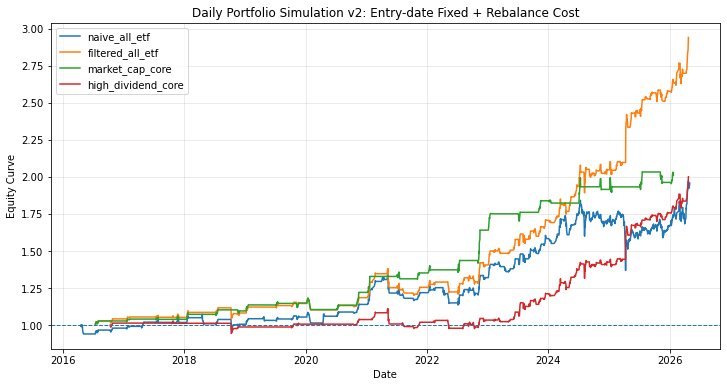

In [14]:

plt.figure(figsize=(12, 6))

for strategy_name, portfolio in daily_portfolio_tables.items():
    if portfolio.empty:
        continue

    x = pd.to_datetime(portfolio["date"]).to_numpy()
    y = portfolio["equity_curve"].to_numpy()

    plt.plot(x, y, label=strategy_name)

plt.axhline(1, linestyle="--", linewidth=1)
plt.title("Daily Portfolio Simulation v2: Entry-date Fixed + Rebalance Cost")
plt.xlabel("Date")
plt.ylabel("Equity Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 12. Daily portfolio drawdowns

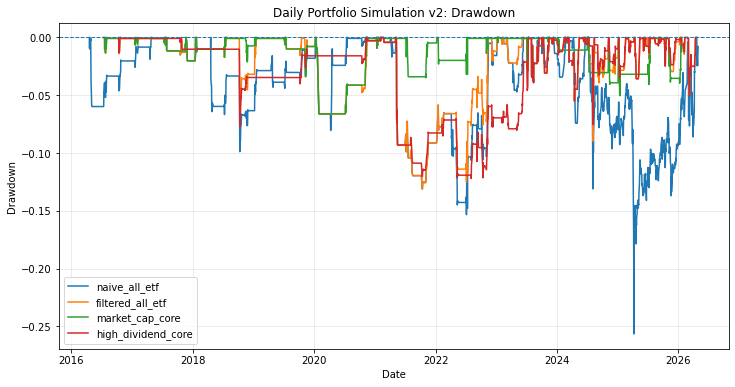

In [15]:

plt.figure(figsize=(12, 6))

for strategy_name, portfolio in daily_portfolio_tables.items():
    if portfolio.empty:
        continue

    x = pd.to_datetime(portfolio["date"]).to_numpy()
    y = portfolio["drawdown"].to_numpy()

    plt.plot(x, y, label=strategy_name)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Daily Portfolio Simulation v2: Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 13. Inspect portfolio states：每日持倉與權重變化

這一段用來檢查策略是否真的照進出場邏輯改變部位。

可看三個表：

1. `portfolio`：每天整體持倉數、turnover、cost、equity curve
2. `holdings`：每天每檔 ETF 權重、單檔報酬、貢獻
3. `rebalance_log`：每天每檔 ETF 權重如何從上一日變成今日


In [16]:

# Change this to inspect another strategy.
INSPECT_STRATEGY = "filtered_all_etf"

portfolio_to_inspect = daily_portfolio_tables[INSPECT_STRATEGY]
holdings_to_inspect = daily_holding_tables[INSPECT_STRATEGY]
rebalance_to_inspect = rebalance_log_tables[INSPECT_STRATEGY]

print("Inspect strategy:", INSPECT_STRATEGY)

print("\nPortfolio states with active positions")
display(
    portfolio_to_inspect[
        portfolio_to_inspect["active_position_count"] > 0
    ][[
        "date",
        "active_position_count",
        "active_symbols",
        "equal_weight",
        "gross_return",
        "rebalance_turnover",
        "rebalance_cost",
        "portfolio_return",
        "equity_curve",
        "drawdown",
    ]].head(80)
)

print("\nHolding details")
display(holdings_to_inspect.head(120))

print("\nRebalance log")
display(rebalance_to_inspect.head(120))


Inspect strategy: filtered_all_etf

Portfolio states with active positions


,date,active_position_count,active_symbols,equal_weight,gross_return,rebalance_turnover,rebalance_cost,portfolio_return,equity_curve,drawdown
1,2016-07-15,1,0050,1.0,0.011817,1.0,0.0008,0.011017,1.011017,0.000000
2,2016-07-18,1,0050,1.0,0.009489,0.0,0.0000,0.009489,1.020610,0.000000
3,2016-07-19,1,0050,1.0,0.001446,0.0,0.0000,0.001446,1.022086,0.000000
4,2016-07-20,2,"0050,006208",0.5,-0.009438,1.0,0.0008,-0.010238,1.011622,-0.010238
5,2016-07-21,2,"0050,006208",0.5,0.009206,0.0,0.0000,0.009206,1.020935,-0.001126
...,...,...,...,...,...,...,...,...,...,...
495,2018-07-19,2,"0050,006208",0.5,0.000779,0.0,0.0000,0.000779,1.094975,-0.002328
496,2018-07-20,2,"0050,006208",0.5,0.015380,0.0,0.0000,0.015380,1.111815,0.000000
497,2018-07-23,1,006208,1.0,0.005738,1.0,0.0008,0.004938,1.117305,0.000000
498,2018-07-24,1,006208,1.0,-0.000408,0.0,0.0000,-0.000408,1.116850,-0.000408



Holding details


,date,symbol,target_weight,daily_ret,contribution,active_position_count
0,2016-07-15,0050,1.0,0.011817,0.011817,1
1,2016-07-18,0050,1.0,0.009489,0.009489,1
2,2016-07-19,0050,1.0,0.001446,0.001446,1
3,2016-07-20,0050,0.5,-0.000722,-0.000361,2
4,2016-07-20,006208,0.5,-0.018154,-0.009077,2
...,...,...,...,...,...,...
115,2018-11-19,006208,0.5,0.000000,0.000000,2
116,2018-11-19,00713,0.5,0.006757,0.003378,2
117,2018-11-20,006208,0.5,-0.010496,-0.005248,2
118,2018-11-20,00713,0.5,-0.003356,-0.001678,2



Rebalance log


,date,symbol,previous_weight,target_weight,weight_change,abs_weight_change,action
0,2016-07-15,0050,0.0,1.0,1.0,1.0,buy/increase
1,2016-07-20,0050,1.0,0.5,-0.5,0.5,sell/decrease
2,2016-07-20,006208,0.0,0.5,0.5,0.5,buy/increase
3,2016-07-28,0050,0.5,0.0,-0.5,0.5,sell/decrease
4,2016-07-28,006208,0.5,1.0,0.5,0.5,buy/increase
...,...,...,...,...,...,...,...
115,2022-12-16,00713,1.0,0.0,-1.0,1.0,sell/decrease
116,2023-01-05,0050,0.0,1.0,1.0,1.0,buy/increase
117,2023-01-30,0050,1.0,0.0,-1.0,1.0,sell/decrease
118,2023-02-03,00878,0.0,1.0,1.0,1.0,buy/increase


## 14. Inspect maximum overlapping positions

In [17]:

for strategy_name, portfolio in daily_portfolio_tables.items():
    if portfolio.empty:
        continue

    print("=" * 80)
    print(strategy_name)

    display(
        portfolio
        .sort_values("active_position_count", ascending=False)
        .head(20)[[
            "date",
            "active_position_count",
            "active_symbols",
            "equal_weight",
            "gross_return",
            "rebalance_turnover",
            "rebalance_cost",
            "portfolio_return",
            "equity_curve",
            "drawdown",
        ]]
    )


naive_all_etf


,date,active_position_count,active_symbols,equal_weight,gross_return,rebalance_turnover,rebalance_cost,portfolio_return,equity_curve,drawdown
2004,2024-07-04,5,"0050,0056,006208,00929,00940",0.20,0.015563,0.4,0.00032,0.015243,1.788409,0.000000
2005,2024-07-05,5,"0050,0056,006208,00929,00940",0.20,-0.000306,0.0,0.00000,-0.000306,1.787862,-0.000306
2006,2024-07-08,5,"0050,0056,006208,00929,00940",0.20,0.012378,0.0,0.00000,0.012378,1.809993,0.000000
2247,2025-07-08,5,"0050,0056,006208,00929,00940",0.20,-0.005090,0.8,0.00064,-0.005730,1.601955,-0.130020
2007,2024-07-09,5,"0050,0056,006208,00929,00940",0.20,0.000027,0.0,0.00000,0.000027,1.810042,0.000000
2248,2025-07-09,5,"0050,0056,006208,00929,00940",0.20,0.010271,0.0,0.00000,0.010271,1.618408,-0.121084
2408,2026-03-10,5,"00713,00919,00929,00939,00940",0.20,0.012952,0.0,0.00000,0.012952,1.722335,-0.064644
2407,2026-03-09,5,"00713,00919,00929,00939,00940",0.20,-0.030316,0.4,0.00032,-0.030636,1.700312,-0.076604
2008,2024-07-10,5,"0050,0056,006208,00929,00940",0.20,0.003542,0.0,0.00000,0.003542,1.816452,0.000000
2192,2025-04-18,4,"0052,0056,00929,00939",0.25,0.001519,0.5,0.00040,0.001119,1.544554,-0.161192


filtered_all_etf


,date,active_position_count,active_symbols,equal_weight,gross_return,rebalance_turnover,rebalance_cost,portfolio_return,equity_curve,drawdown
1708,2023-07-17,3,"0050,0056,006208",0.333333,0.003777,0.000000,0.000000,0.003777,1.615395,0.000000
1949,2024-07-11,3,"0050,0056,006208",0.333333,0.017433,0.000000,0.000000,0.017433,2.078817,0.000000
1061,2020-11-13,3,"006208,00713,00878",0.333333,0.002331,0.000000,0.000000,0.002331,1.163960,-0.013994
1943,2024-07-03,3,"0050,0056,006208",0.333333,0.010478,1.000000,0.000800,0.009678,1.953549,0.000000
1944,2024-07-04,3,"0050,0056,006208",0.333333,0.020905,0.000000,0.000000,0.020905,1.994388,0.000000
1945,2024-07-05,3,"0050,0056,006208",0.333333,-0.001474,0.000000,0.000000,-0.001474,1.991448,-0.001474
1946,2024-07-08,3,"0050,0056,006208",0.333333,0.021594,0.000000,0.000000,0.021594,2.034451,0.000000
1947,2024-07-09,3,"0050,0056,006208",0.333333,-0.000300,0.000000,0.000000,-0.000300,2.033841,-0.000300
1948,2024-07-10,3,"0050,0056,006208",0.333333,0.004600,0.000000,0.000000,0.004600,2.043197,0.000000
1951,2024-07-15,3,"0050,0056,006208",0.333333,-0.000140,0.000000,0.000000,-0.000140,2.033203,-0.021942


market_cap_core


,date,active_position_count,active_symbols,equal_weight,gross_return,rebalance_turnover,rebalance_cost,portfolio_return,equity_curve,drawdown
730,2019-07-08,2,"0050,006208",0.5,-0.002046,1.0,0.0008,-0.002846,1.132560,-0.004014
1464,2022-07-13,2,"0050,006208",0.5,0.034336,0.0,0.0000,0.034336,1.411350,0.000000
1943,2024-07-03,2,"0050,006208",0.5,0.011825,1.0,0.0008,0.011025,1.843186,-0.000038
1944,2024-07-04,2,"0050,006208",0.5,0.025804,0.0,0.0000,0.025804,1.890748,0.000000
1945,2024-07-05,2,"0050,006208",0.5,-0.002928,0.0,0.0000,-0.002928,1.885213,-0.002928
1946,2024-07-08,2,"0050,006208",0.5,0.030007,0.0,0.0000,0.030007,1.941781,0.000000
1947,2024-07-09,2,"0050,006208",0.5,0.000143,0.0,0.0000,0.000143,1.942060,0.000000
1948,2024-07-10,2,"0050,006208",0.5,0.003931,0.0,0.0000,0.003931,1.949693,0.000000
1949,2024-07-11,2,"0050,006208",0.5,0.022489,0.0,0.0000,0.022489,1.993541,0.000000
1950,2024-07-12,2,"0050,006208",0.5,-0.029660,0.0,0.0000,-0.029660,1.934412,-0.029660


high_dividend_core


,date,active_position_count,active_symbols,equal_weight,gross_return,rebalance_turnover,rebalance_cost,portfolio_return,equity_curve,drawdown
1747,2023-12-11,2,"00713,00919",0.5,0.003262,0.0,0.0000,0.003262,1.183115,0.000000
1688,2023-09-14,2,"00713,00919",0.5,0.013793,0.0,0.0000,0.013793,1.154946,0.000000
1805,2024-03-13,2,"00713,00919",0.5,0.015827,0.0,0.0000,0.015827,1.312328,0.000000
1804,2024-03-12,2,"00713,00919",0.5,0.019091,0.0,0.0000,0.019091,1.291882,0.000000
1803,2024-03-11,2,"00713,00919",0.5,-0.001273,0.0,0.0000,-0.001273,1.267680,-0.001895
1802,2024-03-08,2,"00713,00919",0.5,-0.000623,0.0,0.0000,-0.000623,1.269296,-0.000623
1801,2024-03-07,2,"00713,00919",0.5,0.014586,0.0,0.0000,0.014586,1.270087,0.000000
1800,2024-03-06,2,"00713,00919",0.5,0.011751,0.0,0.0000,0.011751,1.251828,0.000000
2043,2025-03-10,2,"00713,00919",0.5,-0.001326,1.0,0.0008,-0.002126,1.443820,-0.003787
2044,2025-03-11,2,"00713,00919",0.5,-0.008232,0.0,0.0000,-0.008232,1.431934,-0.011988


## 15. Plot active position count

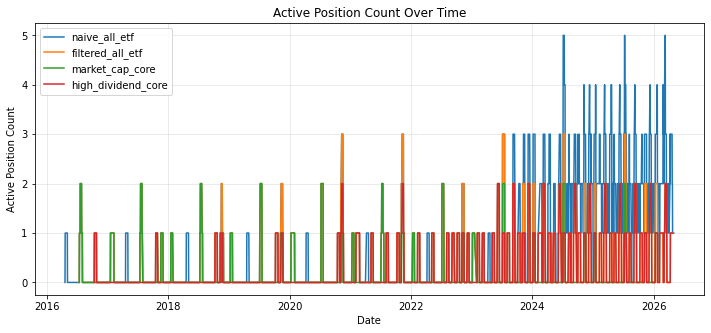

In [18]:

plt.figure(figsize=(12, 5))

for strategy_name, portfolio in daily_portfolio_tables.items():
    if portfolio.empty:
        continue

    x = pd.to_datetime(portfolio["date"]).to_numpy()
    y = portfolio["active_position_count"].to_numpy()

    plt.plot(x, y, label=strategy_name)

plt.title("Active Position Count Over Time")
plt.xlabel("Date")
plt.ylabel("Active Position Count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 16. Export daily portfolio v2 outputs

In [19]:

daily_portfolio_summary.to_csv(
    OUTPUT_DIR / "daily_portfolio_summary_v2_cost_rebalance.csv",
    index=False,
    encoding="utf-8-sig",
)

for strategy_name, portfolio in daily_portfolio_tables.items():
    portfolio.to_csv(
        OUTPUT_DIR / f"{strategy_name}_daily_portfolio_v2.csv",
        index=False,
        encoding="utf-8-sig",
    )

for strategy_name, holdings in daily_holding_tables.items():
    holdings.to_csv(
        OUTPUT_DIR / f"{strategy_name}_daily_holdings_v2.csv",
        index=False,
        encoding="utf-8-sig",
    )

for strategy_name, rebalance_log in rebalance_log_tables.items():
    rebalance_log.to_csv(
        OUTPUT_DIR / f"{strategy_name}_rebalance_log_v2.csv",
        index=False,
        encoding="utf-8-sig",
    )

for strategy_name, trades in strategy_trade_tables.items():
    trades.to_csv(
        OUTPUT_DIR / f"{strategy_name}_trades.csv",
        index=False,
        encoding="utf-8-sig",
    )

print("Saved daily portfolio v2 outputs to:", OUTPUT_DIR)


Saved daily portfolio v2 outputs to: C:\Users\USER\Desktop\ETF-alpha-lab\data\strategy


## 17. Interpretation checklist

這版已修正兩個重要問題：

1. `entry_date` 收盤買進，因此不吃 `entry_date` 當日報酬。
2. 每日重新等權時加入 turnover transaction cost。

重點檢查：

- `filtered_all_etf` 是否仍優於 `naive_all_etf`
- `market_cap_core` 是否仍最穩
- 加入成本後報酬是否仍合理
- `rebalance_log` 是否符合預期：
  - 新 ETF 進來時，原持倉被降權
  - ETF 出場後，剩餘持倉被重新等權
- `active_position_count` 是否與策略事件密集程度一致

下一版可加入：

- announcement_date 可交易性檢查
- slippage sensitivity
- 單檔權重上限
- 不同類別不同權重


## 18. Strategy v3：Market risk filter

這一段測試市場風險濾網。

目的：

> 避免在大盤明顯偏弱時，仍然硬做除息前卡位策略。

目前策略本質上是 long-only ETF strategy，仍會受到整體台股市場方向影響。  
因此這裡用 `0050` 作為市場風險代理變數。

### 本版測試四種 market filter

1. `0050_above_ma60`
   - 0050 價格高於 60 日均線

2. `0050_above_ma120`
   - 0050 價格高於 120 日均線

3. `0050_ret20_gt_minus5`
   - 0050 過去 20 日報酬 > -5%

4. `0050_above_ma60_and_ret20_gt_minus5`
   - 同時符合 60MA 趨勢與短期跌幅控制

### 保守設定

為了避免使用進場日收盤才知道的資訊，本版預設用：

```python
entry_date 前一個交易日的市場狀態
```

來決定 `entry_date` 是否可以進場。


In [20]:
def build_market_regime_table(
    panel_all,
    benchmark_symbol="0050",
    price_col="adj_close",
    ma_short=60,
    ma_long=120,
    ret_window=20,
):
    """
    Build market regime filters using a benchmark ETF, default 0050.
    """

    benchmark_symbol = fix_tw_etf_symbol(benchmark_symbol)

    mkt = panel_all[
        panel_all["symbol"].apply(fix_tw_etf_symbol) == benchmark_symbol
    ][["date", "symbol", price_col]].copy()

    mkt["date"] = pd.to_datetime(mkt["date"], errors="coerce")
    mkt = mkt.dropna(subset=["date", price_col])
    mkt = mkt.sort_values("date").reset_index(drop=True)

    mkt["ma60"] = mkt[price_col].rolling(ma_short).mean()
    mkt["ma120"] = mkt[price_col].rolling(ma_long).mean()
    mkt["ret20"] = mkt[price_col].pct_change(ret_window)

    mkt["0050_above_ma60"] = mkt[price_col] > mkt["ma60"]
    mkt["0050_above_ma120"] = mkt[price_col] > mkt["ma120"]
    mkt["0050_ret20_gt_minus5"] = mkt["ret20"] > -0.05
    mkt["0050_above_ma60_and_ret20_gt_minus5"] = (
        mkt["0050_above_ma60"]
        & mkt["0050_ret20_gt_minus5"]
    )

    return mkt


market_regime = build_market_regime_table(
    panel_all=panel_all,
    benchmark_symbol="0050",
    price_col="adj_close",
    ma_short=60,
    ma_long=120,
    ret_window=20,
)

print("market_regime shape:", market_regime.shape)
display(market_regime.tail())


market_regime shape: (2517, 10)


,date,symbol,adj_close,ma60,ma120,ret20,0050_above_ma60,0050_above_ma120,0050_ret20_gt_minus5,0050_above_ma60_and_ret20_gt_minus5
2512,2026-05-12,0050,96.849998,81.024166,73.014222,0.201613,True,True,True,True
2513,2026-05-13,0050,95.500000,81.400000,73.296060,0.149218,True,True,True,True
2514,2026-05-14,0050,96.050003,81.785833,73.575908,0.141414,True,True,True,True
2515,2026-05-15,0050,95.400002,82.175833,73.854036,0.122353,True,True,True,True
2516,2026-05-18,0050,94.900002,82.559166,74.125533,0.127748,True,True,True,True


## 19. Apply market filter to trades

這裡會將 market filter 套到每一筆 trade。

### 重要設計

這裡不用 `entry_date` 當天的市場狀態，而是用：

```python
entry_date 前一個交易日
```

的市場狀態來決定是否進場。

原因：

- 策略假設 `entry_date` 收盤買進。
- 如果用 `entry_date` 當天收盤價判斷 0050 是否高於均線，再同一天收盤買進，會有一點時間點問題。
- 用前一交易日狀態比較保守，也比較乾淨。


In [21]:
def add_market_filter_to_trades(
    trades,
    market_regime,
    filter_col,
):
    """
    Add market filter information to trades.

    Uses previous benchmark trading day before entry_date as the decision date.
    """

    if trades.empty:
        return trades.copy()

    trades = trades.copy()
    trades["entry_date"] = pd.to_datetime(trades["entry_date"], errors="coerce")

    mkt = market_regime.copy()
    mkt["date"] = pd.to_datetime(mkt["date"], errors="coerce")
    mkt = mkt.sort_values("date").reset_index(drop=True)

    market_dates = mkt["date"].to_numpy()

    decision_dates = []
    filter_values = []

    for entry_date in trades["entry_date"]:
        idx = market_dates.searchsorted(entry_date.to_datetime64())

        # Use previous market date before entry_date.
        decision_idx = idx - 1

        if decision_idx < 0:
            decision_dates.append(pd.NaT)
            filter_values.append(False)
            continue

        decision_row = mkt.iloc[decision_idx]
        decision_dates.append(decision_row["date"])

        value = decision_row[filter_col]
        filter_values.append(bool(value) if pd.notna(value) else False)

    trades["market_filter_name"] = filter_col
    trades["market_decision_date"] = decision_dates
    trades["market_filter_pass"] = filter_values

    return trades


def build_market_filtered_trade_tables(
    strategy_trade_tables,
    market_regime,
    filter_col,
):
    filtered_tables = {}

    for strategy_name, trades in strategy_trade_tables.items():
        trades_with_filter = add_market_filter_to_trades(
            trades=trades,
            market_regime=market_regime,
            filter_col=filter_col,
        )

        filtered_tables[strategy_name] = trades_with_filter[
            trades_with_filter["market_filter_pass"]
        ].copy()

    return filtered_tables


MARKET_FILTER_COLUMNS = [
    "0050_above_ma60",
    "0050_above_ma120",
    "0050_ret20_gt_minus5",
    "0050_above_ma60_and_ret20_gt_minus5",
]

# Quick check on filtered_all_etf
sample_filter = "0050_above_ma60"

sample_trades_with_filter = add_market_filter_to_trades(
    trades=strategy_trade_tables["filtered_all_etf"],
    market_regime=market_regime,
    filter_col=sample_filter,
)

display(
    sample_trades_with_filter[[
        "event_id",
        "symbol",
        "entry_date",
        "market_decision_date",
        "market_filter_name",
        "market_filter_pass",
    ]].head(20)
)

display(
    sample_trades_with_filter["market_filter_pass"].value_counts(dropna=False).to_frame("count")
)


,event_id,symbol,entry_date,market_decision_date,market_filter_name,market_filter_pass
0,0050_20160728,0050,2016-07-14,2016-07-13,0050_above_ma60,True
1,006208_20160802,006208,2016-07-19,2016-07-18,0050_above_ma60,True
2,0056_20161026,0056,2016-10-12,2016-10-11,0050_above_ma60,True
3,0050_20170208,0050,2017-01-17,2017-01-16,0050_above_ma60,True
4,006208_20170727,006208,2017-07-13,2017-07-12,0050_above_ma60,True
5,0050_20170731,0050,2017-07-17,2017-07-14,0050_above_ma60,True
6,0056_20171030,0056,2017-10-16,2017-10-13,0050_above_ma60,True
7,006208_20171130,006208,2017-11-16,2017-11-15,0050_above_ma60,True
8,0050_20180129,0050,2018-01-15,2018-01-12,0050_above_ma60,True
9,0050_20180723,0050,2018-07-09,2018-07-06,0050_above_ma60,False


,count
market_filter_pass,
True,78
False,33


## 20. Run market-filtered daily portfolio simulations

這裡會對每一種 market filter 重新跑：

```python
build_daily_equal_weight_portfolio_v2()
```

所以仍然保留：

- 不吃進場日報酬
- 重疊持倉動態等權
- 再平衡 turnover cost


In [22]:
def run_market_filter_backtests(
    strategy_trade_tables,
    market_regime,
    filter_cols,
):
    all_summary_rows = []
    all_portfolio_tables = {}
    all_holding_tables = {}
    all_rebalance_tables = {}
    all_filtered_trade_tables = {}

    for filter_col in filter_cols:
        filtered_trade_tables = build_market_filtered_trade_tables(
            strategy_trade_tables=strategy_trade_tables,
            market_regime=market_regime,
            filter_col=filter_col,
        )

        all_filtered_trade_tables[filter_col] = filtered_trade_tables

        for strategy_name, trades in filtered_trade_tables.items():
            portfolio, holdings, rebalance_log = build_daily_equal_weight_portfolio_v2(
                trades=trades,
                panel_all=panel_all,
                price_col="adj_close",
                initial_capital=1.0,
                rebalance_cost_rate=STRATEGY_FEE_RATE,
            )

            key = f"{filter_col}__{strategy_name}"

            all_portfolio_tables[key] = portfolio
            all_holding_tables[key] = holdings
            all_rebalance_tables[key] = rebalance_log

            summary = summarize_daily_portfolio_v2(portfolio)
            summary["market_filter"] = filter_col
            summary["strategy"] = strategy_name
            summary["raw_trade_count"] = len(strategy_trade_tables[strategy_name])
            summary["filtered_trade_count"] = len(trades)
            summary["trade_keep_ratio"] = (
                len(trades) / len(strategy_trade_tables[strategy_name])
                if len(strategy_trade_tables[strategy_name]) > 0
                else np.nan
            )

            all_summary_rows.append(summary)

    summary_df = pd.DataFrame(all_summary_rows)

    if not summary_df.empty:
        summary_df = summary_df[
            ["market_filter", "strategy", "raw_trade_count", "filtered_trade_count", "trade_keep_ratio"]
            + [
                c for c in summary_df.columns
                if c not in ["market_filter", "strategy", "raw_trade_count", "filtered_trade_count", "trade_keep_ratio"]
            ]
        ]

    return summary_df, all_portfolio_tables, all_holding_tables, all_rebalance_tables, all_filtered_trade_tables


market_filter_summary, market_filter_portfolio_tables, market_filter_holding_tables, market_filter_rebalance_tables, market_filtered_trade_tables = run_market_filter_backtests(
    strategy_trade_tables=strategy_trade_tables,
    market_regime=market_regime,
    filter_cols=MARKET_FILTER_COLUMNS,
)

display(format_portfolio_summary_for_display_v2(market_filter_summary))


,market_filter,strategy,raw_trade_count,filtered_trade_count,trade_keep_ratio,trading_days,total_return,annualized_return,annualized_vol,sharpe_like,...,median_daily_return,avg_active_positions,max_active_positions,exposure_rate,avg_turnover,total_turnover,avg_rebalance_cost,total_rebalance_cost,start_date,end_date
0,0050_above_ma60,naive_all_etf,198,148,0.747475,2444,65.977177,5.363239,8.406896,0.637957,...,0.0,0.546236,5,31.751227,9.698582,23703.333333,0.007759,18.962667,2016-04-19,2026-04-30
1,0050_above_ma60,filtered_all_etf,111,78,0.702703,2378,103.708424,7.831617,6.947717,1.127222,...,0.0,0.295206,3,21.404542,5.424727,12900.000000,0.004340,10.320000,2016-07-14,2026-04-22
2,0050_above_ma60,market_cap_core,39,29,0.743590,2323,38.820010,3.622308,4.780147,0.757782,...,0.0,0.112355,2,8.652604,2.195437,5100.000000,0.001756,4.080000,2016-07-14,2026-01-21
3,0050_above_ma60,high_dividend_core,72,49,0.680556,2316,61.720805,5.369631,5.787581,0.927785,...,0.0,0.190415,2,16.321244,3.929188,9100.000000,0.003143,7.280000,2016-10-12,2026-04-22
4,0050_above_ma120,naive_all_etf,198,155,0.782828,2384,70.760152,5.819169,8.589781,0.677453,...,0.0,0.586409,5,32.843960,10.194351,24303.333333,0.008155,19.442667,2016-07-14,2026-04-30
5,0050_above_ma120,filtered_all_etf,111,85,0.765766,2378,88.409336,6.943154,7.291491,0.952227,...,0.0,0.321699,3,22.666106,5.761144,13700.000000,0.004609,10.960000,2016-07-14,2026-04-22
6,0050_above_ma120,market_cap_core,39,29,0.743590,2323,38.333313,3.582835,5.000950,0.716431,...,0.0,0.112355,2,8.652604,2.195437,5100.000000,0.001756,4.080000,2016-07-14,2026-01-21
7,0050_above_ma120,high_dividend_core,72,56,0.777778,2316,58.688861,5.152866,6.302061,0.817648,...,0.0,0.217617,2,18.393782,4.447323,10300.000000,0.003558,8.240000,2016-10-12,2026-04-22
8,0050_ret20_gt_minus5,naive_all_etf,198,181,0.914141,2444,96.665978,7.222597,9.226824,0.782783,...,0.0,0.667758,5,37.765957,11.689853,28570.000000,0.009352,22.856000,2016-04-19,2026-04-30
9,0050_ret20_gt_minus5,filtered_all_etf,111,102,0.918919,2378,153.748129,10.371041,7.753440,1.337605,...,0.0,0.386039,3,27.207738,6.938604,16500.000000,0.005551,13.200000,2016-07-14,2026-04-22


## 21. Compare base vs market-filtered strategies

這裡把原始 v2 結果與 market filter 結果放在一起比較。

重點看：

1. `filtered_all_etf` 的年化報酬是否維持
2. `max_drawdown` 是否下降
3. `sharpe_like` 是否提高
4. `trade_keep_ratio` 是否不要太低

如果濾網讓交易數大幅下降，但 Sharpe 沒變好，就不值得用。


In [23]:
base_compare = daily_portfolio_summary.copy()
base_compare["market_filter"] = "base_no_market_filter"
base_compare["raw_trade_count"] = np.nan
base_compare["filtered_trade_count"] = np.nan
base_compare["trade_keep_ratio"] = np.nan

base_compare = base_compare[
    ["market_filter", "strategy", "raw_trade_count", "filtered_trade_count", "trade_keep_ratio"]
    + [
        c for c in base_compare.columns
        if c not in ["market_filter", "strategy", "raw_trade_count", "filtered_trade_count", "trade_keep_ratio"]
    ]
]

market_filter_comparison = pd.concat(
    [base_compare, market_filter_summary],
    ignore_index=True,
)

display(format_portfolio_summary_for_display_v2(market_filter_comparison))


,market_filter,strategy,raw_trade_count,filtered_trade_count,trade_keep_ratio,trading_days,total_return,annualized_return,annualized_vol,sharpe_like,...,median_daily_return,avg_active_positions,max_active_positions,exposure_rate,avg_turnover,total_turnover,avg_rebalance_cost,total_rebalance_cost,start_date,end_date
0,base_no_market_filter,naive_all_etf,NaN,NaN,NaN,2444,95.697939,7.168057,11.140180,0.643442,...,0.0,0.730360,5,41.448445,12.685488,31003.333333,0.010148,24.802667,2016-04-19,2026-04-30
1,base_no_market_filter,filtered_all_etf,NaN,NaN,NaN,2378,194.011401,12.107123,8.882863,1.362975,...,0.0,0.420101,3,29.814971,7.611438,18100.000000,0.006089,14.480000,2016-07-14,2026-04-22
2,base_no_market_filter,market_cap_core,NaN,NaN,NaN,2323,100.982857,7.866557,6.262260,1.256185,...,0.0,0.151098,2,11.881188,2.970297,6900.000000,0.002376,5.520000,2016-07-14,2026-01-21
3,base_no_market_filter,high_dividend_core,NaN,NaN,NaN,2316,100.088187,7.838885,7.596022,1.031972,...,0.0,0.279793,2,23.834197,5.829016,13500.000000,0.004663,10.800000,2016-10-12,2026-04-22
4,0050_above_ma60,naive_all_etf,198.0,148.0,0.747475,2444,65.977177,5.363239,8.406896,0.637957,...,0.0,0.546236,5,31.751227,9.698582,23703.333333,0.007759,18.962667,2016-04-19,2026-04-30
5,0050_above_ma60,filtered_all_etf,111.0,78.0,0.702703,2378,103.708424,7.831617,6.947717,1.127222,...,0.0,0.295206,3,21.404542,5.424727,12900.000000,0.004340,10.320000,2016-07-14,2026-04-22
6,0050_above_ma60,market_cap_core,39.0,29.0,0.743590,2323,38.820010,3.622308,4.780147,0.757782,...,0.0,0.112355,2,8.652604,2.195437,5100.000000,0.001756,4.080000,2016-07-14,2026-01-21
7,0050_above_ma60,high_dividend_core,72.0,49.0,0.680556,2316,61.720805,5.369631,5.787581,0.927785,...,0.0,0.190415,2,16.321244,3.929188,9100.000000,0.003143,7.280000,2016-10-12,2026-04-22
8,0050_above_ma120,naive_all_etf,198.0,155.0,0.782828,2384,70.760152,5.819169,8.589781,0.677453,...,0.0,0.586409,5,32.843960,10.194351,24303.333333,0.008155,19.442667,2016-07-14,2026-04-30
9,0050_above_ma120,filtered_all_etf,111.0,85.0,0.765766,2378,88.409336,6.943154,7.291491,0.952227,...,0.0,0.321699,3,22.666106,5.761144,13700.000000,0.004609,10.960000,2016-07-14,2026-04-22


## 22. Focus table：Filtered All ETF only

先聚焦在目前主策略 `filtered_all_etf`。

這張表用來判斷 market filter 是否真的改善主策略。


In [24]:
filtered_focus = market_filter_comparison[
    market_filter_comparison["strategy"] == "filtered_all_etf"
].copy()

filtered_focus = filtered_focus.sort_values(
    ["sharpe_like", "max_drawdown", "annualized_return"],
    ascending=[False, False, False],
).reset_index(drop=True)

display(format_portfolio_summary_for_display_v2(filtered_focus))


,market_filter,strategy,raw_trade_count,filtered_trade_count,trade_keep_ratio,trading_days,total_return,annualized_return,annualized_vol,sharpe_like,...,median_daily_return,avg_active_positions,max_active_positions,exposure_rate,avg_turnover,total_turnover,avg_rebalance_cost,total_rebalance_cost,start_date,end_date
0,base_no_market_filter,filtered_all_etf,NaN,NaN,NaN,2378,194.011401,12.107123,8.882863,1.362975,...,0.0,0.420101,3,29.814971,7.611438,18100.0,0.006089,14.48,2016-07-14,2026-04-22
1,0050_ret20_gt_minus5,filtered_all_etf,111.0,102.0,0.918919,2378,153.748129,10.371041,7.753440,1.337605,...,0.0,0.386039,3,27.207738,6.938604,16500.0,0.005551,13.20,2016-07-14,2026-04-22
2,0050_above_ma60,filtered_all_etf,111.0,78.0,0.702703,2378,103.708424,7.831617,6.947717,1.127222,...,0.0,0.295206,3,21.404542,5.424727,12900.0,0.004340,10.32,2016-07-14,2026-04-22
3,0050_above_ma60_and_ret20_gt_minus5,filtered_all_etf,111.0,77.0,0.693694,2378,90.903557,7.092303,6.829780,1.038438,...,0.0,0.291421,3,21.026072,5.340622,12700.0,0.004272,10.16,2016-07-14,2026-04-22
4,0050_above_ma120,filtered_all_etf,111.0,85.0,0.765766,2378,88.409336,6.943154,7.291491,0.952227,...,0.0,0.321699,3,22.666106,5.761144,13700.0,0.004609,10.96,2016-07-14,2026-04-22


## 23. Plot equity curves：Filtered All ETF market filters

這裡只畫 `filtered_all_etf` 的原始版本與不同 market filter 版本。


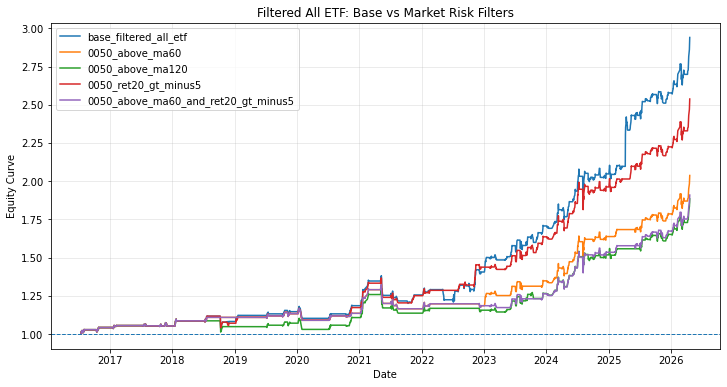

In [25]:
plt.figure(figsize=(12, 6))

# Base filtered_all_etf
base_portfolio = daily_portfolio_tables["filtered_all_etf"]
plt.plot(
    pd.to_datetime(base_portfolio["date"]).to_numpy(),
    base_portfolio["equity_curve"].to_numpy(),
    label="base_filtered_all_etf",
)

for filter_col in MARKET_FILTER_COLUMNS:
    key = f"{filter_col}__filtered_all_etf"
    portfolio = market_filter_portfolio_tables.get(key)

    if portfolio is None or portfolio.empty:
        continue

    plt.plot(
        pd.to_datetime(portfolio["date"]).to_numpy(),
        portfolio["equity_curve"].to_numpy(),
        label=filter_col,
    )

plt.axhline(1, linestyle="--", linewidth=1)
plt.title("Filtered All ETF: Base vs Market Risk Filters")
plt.xlabel("Date")
plt.ylabel("Equity Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 24. Plot drawdowns：Filtered All ETF market filters

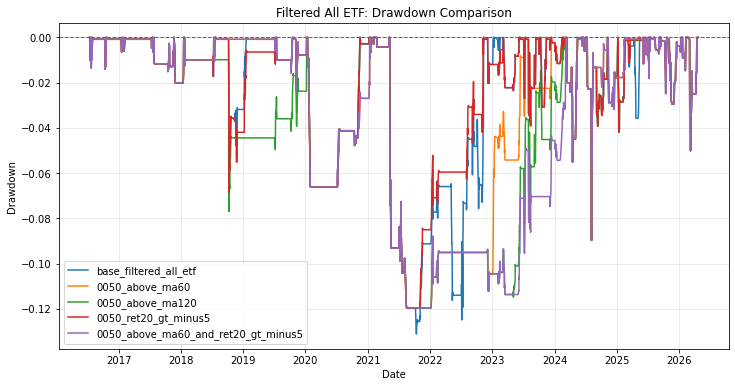

In [26]:
plt.figure(figsize=(12, 6))

# Base filtered_all_etf
base_portfolio = daily_portfolio_tables["filtered_all_etf"]
plt.plot(
    pd.to_datetime(base_portfolio["date"]).to_numpy(),
    base_portfolio["drawdown"].to_numpy(),
    label="base_filtered_all_etf",
)

for filter_col in MARKET_FILTER_COLUMNS:
    key = f"{filter_col}__filtered_all_etf"
    portfolio = market_filter_portfolio_tables.get(key)

    if portfolio is None or portfolio.empty:
        continue

    plt.plot(
        pd.to_datetime(portfolio["date"]).to_numpy(),
        portfolio["drawdown"].to_numpy(),
        label=filter_col,
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Filtered All ETF: Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 25. Inspect filtered trades removed by market filter

這裡可以檢查 market filter 到底刪掉了哪些交易。

預設檢查主策略 `filtered_all_etf` + `0050_above_ma60`。


In [27]:
INSPECT_MARKET_FILTER = "0050_above_ma60"
INSPECT_STRATEGY = "filtered_all_etf"

trades_with_filter = add_market_filter_to_trades(
    trades=strategy_trade_tables[INSPECT_STRATEGY],
    market_regime=market_regime,
    filter_col=INSPECT_MARKET_FILTER,
)

removed_trades = trades_with_filter[
    ~trades_with_filter["market_filter_pass"]
].copy()

kept_trades = trades_with_filter[
    trades_with_filter["market_filter_pass"]
].copy()

print("Inspect strategy:", INSPECT_STRATEGY)
print("Inspect market filter:", INSPECT_MARKET_FILTER)
print("Raw trades:", len(trades_with_filter))
print("Kept trades:", len(kept_trades))
print("Removed trades:", len(removed_trades))

print("\nRemoved trades")
display(
    removed_trades[[
        "event_id",
        "symbol",
        "etf_name",
        "entry_date",
        "exit_date",
        "ex_date",
        "market_decision_date",
        "market_filter_name",
        "market_filter_pass",
        "net_return",
    ]].head(50)
)

print("\nKept trades")
display(
    kept_trades[[
        "event_id",
        "symbol",
        "etf_name",
        "entry_date",
        "exit_date",
        "ex_date",
        "market_decision_date",
        "market_filter_name",
        "market_filter_pass",
        "net_return",
    ]].head(50)
)


Inspect strategy: filtered_all_etf
Inspect market filter: 0050_above_ma60
Raw trades: 111
Kept trades: 78
Removed trades: 33

Removed trades


,event_id,symbol,etf_name,entry_date,exit_date,ex_date,market_decision_date,market_filter_name,market_filter_pass,net_return
9,0050_20180723,0050,元大台灣50,2018-07-09,2018-07-20,2018-07-23,2018-07-06,0050_above_ma60,False,0.027579
11,0056_20181023,0056,元大高股息,2018-10-08,2018-10-22,2018-10-23,2018-10-05,0050_above_ma60,False,-0.034933
12,00713_20181122,00713,元大台灣高息低波,2018-11-08,2018-11-21,2018-11-22,2018-11-07,0050_above_ma60,False,0.010591
13,006208_20181129,006208,富邦台50,2018-11-15,2018-11-28,2018-11-29,2018-11-14,0050_above_ma60,False,-0.006508
14,0050_20190122,0050,元大台灣50,2019-01-08,2019-01-21,2019-01-22,2019-01-07,0050_above_ma60,False,0.037096
24,006208_20201117,006208,富邦台50,2020-11-03,2020-11-16,2020-11-17,2020-11-02,0050_above_ma60,False,0.076094
25,00878_20201117,00878,國泰永續高股息,2020-11-03,2020-11-16,2020-11-17,2020-11-02,0050_above_ma60,False,0.039061
33,0056_20211022,0056,元大高股息,2021-10-07,2021-10-21,2021-10-22,2021-10-06,0050_above_ma60,False,-0.006820
34,006208_20211116,006208,富邦台50,2021-11-02,2021-11-15,2021-11-16,2021-11-01,0050_above_ma60,False,0.030288
35,00878_20211116,00878,國泰永續高股息,2021-11-02,2021-11-15,2021-11-16,2021-11-01,0050_above_ma60,False,0.026208



Kept trades


,event_id,symbol,etf_name,entry_date,exit_date,ex_date,market_decision_date,market_filter_name,market_filter_pass,net_return
0,0050_20160728,0050,元大台灣50,2016-07-14,2016-07-27,2016-07-28,2016-07-13,0050_above_ma60,True,0.027942
1,006208_20160802,006208,富邦台50,2016-07-19,2016-08-01,2016-08-02,2016-07-18,0050_above_ma60,True,0.001930
2,0056_20161026,0056,元大高股息,2016-10-12,2016-10-25,2016-10-26,2016-10-11,0050_above_ma60,True,0.013618
3,0050_20170208,0050,元大台灣50,2017-01-17,2017-02-07,2017-02-08,2017-01-16,0050_above_ma60,True,0.012231
4,006208_20170727,006208,富邦台50,2017-07-13,2017-07-26,2017-07-27,2017-07-12,0050_above_ma60,True,0.001703
5,0050_20170731,0050,元大台灣50,2017-07-17,2017-07-28,2017-07-31,2017-07-14,0050_above_ma60,True,-0.002816
6,0056_20171030,0056,元大高股息,2017-10-16,2017-10-27,2017-10-30,2017-10-13,0050_above_ma60,True,-0.001221
7,006208_20171130,006208,富邦台50,2017-11-16,2017-11-29,2017-11-30,2017-11-15,0050_above_ma60,True,0.000440
8,0050_20180129,0050,元大台灣50,2018-01-15,2018-01-26,2018-01-29,2018-01-12,0050_above_ma60,True,0.032068
10,006208_20180726,006208,富邦台50,2018-07-12,2018-07-25,2018-07-26,2018-07-11,0050_above_ma60,True,0.020900


## 26. Export market filter outputs

In [28]:
market_filter_summary.to_csv(
    OUTPUT_DIR / "market_filter_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

market_filter_comparison.to_csv(
    OUTPUT_DIR / "market_filter_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

filtered_focus.to_csv(
    OUTPUT_DIR / "market_filter_filtered_all_etf_focus.csv",
    index=False,
    encoding="utf-8-sig",
)

for filter_col, trade_tables in market_filtered_trade_tables.items():
    for strategy_name, trades in trade_tables.items():
        trades.to_csv(
            OUTPUT_DIR / f"{strategy_name}_{filter_col}_trades.csv",
            index=False,
            encoding="utf-8-sig",
        )

for key, portfolio in market_filter_portfolio_tables.items():
    portfolio.to_csv(
        OUTPUT_DIR / f"{key}_daily_portfolio.csv",
        index=False,
        encoding="utf-8-sig",
    )

print("Saved market filter outputs to:", OUTPUT_DIR)


Saved market filter outputs to: C:\Users\USER\Desktop\ETF-alpha-lab\data\strategy


## 27. Interpretation checklist：Market risk filter

解讀順序：

1. 先看 `filtered_focus`
   - 哪個 filter 的 `sharpe_like` 最高？
   - 哪個 filter 的 `max_drawdown` 最低？
   - 哪個 filter 的 `annualized_return` 沒有被犧牲太多？

2. 再看 `trade_keep_ratio`
   - 如果保留交易太少，結果可能不穩。
   - 通常希望至少保留 50% 以上交易，除非風控效果非常明顯。

3. 看 equity curve
   - market filter 是否讓曲線更平滑？
   - 是否少掉大跌段？

4. 看 drawdown
   - 目標是把 `filtered_all_etf` 原本約 -13% 的 max drawdown 壓低。
   - 如果能降到 -10% 以下，同時 Sharpe-like 不下降，就是很好的 filter。

5. 看 removed trades
   - 檢查被濾掉的交易是否集中在市場弱勢期。
   - 如果濾掉很多原本會賺的交易，代表 filter 太嚴。
